# R03 — Damage Analysis

**Goal:** Understand damage dealt vs received per opponent.

**Net damage** = damage we deal − damage we receive. Positive means we're
winning the damage exchange. This is the most direct measure of combat effectiveness.

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

scores = add_opponent_names(load_local_scores())
print(f'Loaded {len(scores):,} score rows')

Indexed 16 ticks.csv files across 3 distinct robots from 1 root(s).
Selected 3 robots × ~100 battles = 16 (battle, robot) pairs to load.
Loaded 16 scores.csv files → 426 rows × 17 cols, 3 robots (~0.1 MB)
Loaded 213 score rows


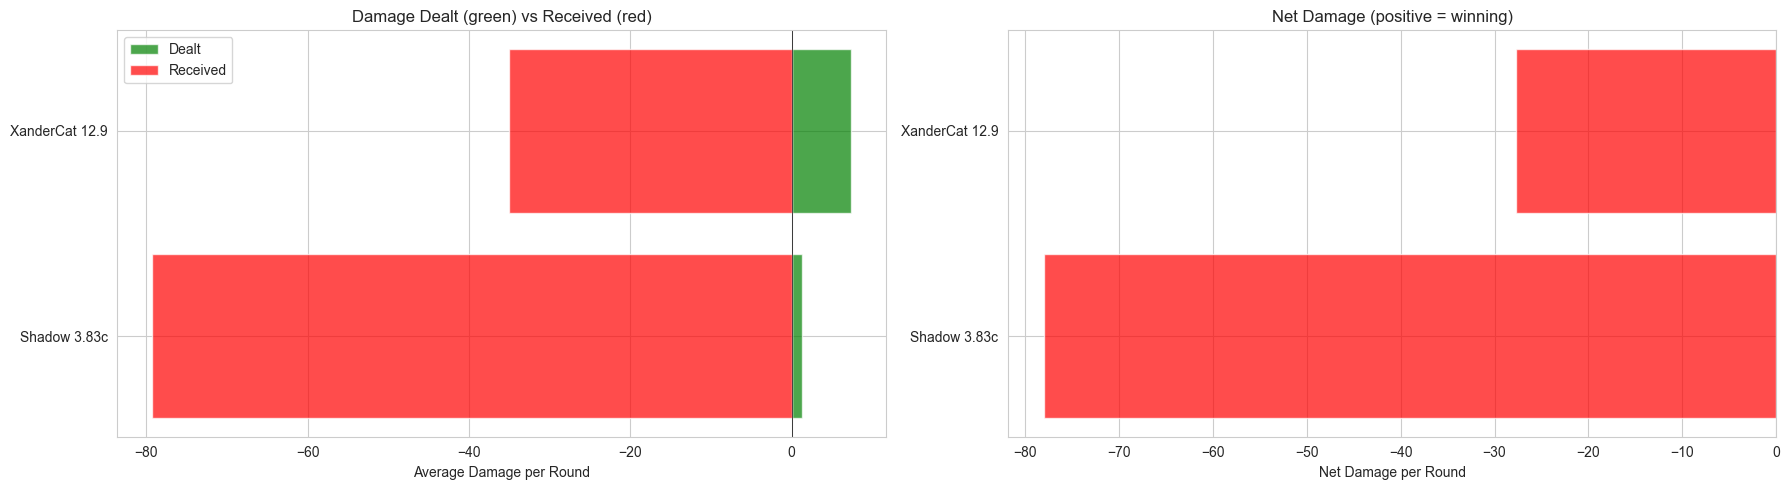

 opponent_name  dealt  received  rounds   net
  Shadow 3.83c    1.3      79.2     108 -77.9
XanderCat 12.9    7.3      35.0     105 -27.7


In [2]:
# Damage dealt vs received per opponent
opp = scores.groupby('opponent_name').agg(
    dealt=('damage_dealt', 'mean'),
    received=('damage_received', 'mean'),
    rounds=('round', 'count'),
).reset_index()
opp['net'] = opp['dealt'] - opp['received']
opp = opp.sort_values('net')

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(opp)*0.5)))

# Stacked bar: dealt vs received
ax = axes[0]
ax.barh(opp['opponent_name'], opp['dealt'], color='green', alpha=0.7, label='Dealt')
ax.barh(opp['opponent_name'], -opp['received'], color='red', alpha=0.7, label='Received')
ax.set_xlabel('Average Damage per Round')
ax.set_title('Damage Dealt (green) vs Received (red)')
ax.legend()
ax.axvline(x=0, color='black', linewidth=0.5)

# Net damage
ax = axes[1]
colors = ['green' if x > 0 else 'red' for x in opp['net']]
ax.barh(opp['opponent_name'], opp['net'], color=colors, alpha=0.7)
ax.set_xlabel('Net Damage per Round')
ax.set_title('Net Damage (positive = winning)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(opp.to_string(index=False, float_format=lambda x: f'{x:.1f}'))